# Part a

In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt

def custom_beta_pdf(theta, alpha, beta_param):
    """
    Manually computes the Beta probability density function.
    f(theta) = Gamma(a+b)/(Gamma(a)*Gamma(b)) * theta^(a-1) * (1-theta)^(b-1)
    """
    if theta <= 0.0 or theta >= 1.0:
        return 0.0

    coef = math.gamma(alpha + beta_param) / (math.gamma(alpha) * math.gamma(beta_param))
    return coef * (theta**(alpha - 1)) * ((1 - theta)**(beta_param - 1))

def binomial_likelihood(theta, n_trials, h_successes):
    """
    Computes the likelihood of observing h successes in n trials.
    L(theta|data) = C(n, h) * theta^h * (1-theta)^(n-h)
    """
    combinations = math.comb(n_trials, h_successes)
    return combinations * (theta**h_successes) * ((1 - theta)**(n_trials - h_successes))

def bayesian_inference_solver(prior_func, data, theta_grid):
    """
    Computes the posterior distribution via numerical grid approximation.
    """
    n_trials, h_successes = data
    
    # Evaluate Prior and Likelihood across the grid
    prior_vals = np.array([prior_func(t) for t in theta_grid])
    likelihood_vals = np.array([binomial_likelihood(t, n_trials, h_successes) for t in theta_grid])
    
    # Multiply to get the Unnormalized Posterior
    unnormalized_posterior = likelihood_vals * prior_vals
    
    # Normalize numerically (trapezoidal rule)
    normalization_constant = np.trapz(unnormalized_posterior, theta_grid)
    posterior_vals = unnormalized_posterior / normalization_constant
    
    return posterior_vals

# Part b

Total Flips (N): 500
Total Heads (h): 356


C:\Users\allst\AppData\Local\Temp\ipykernel_33708\2064201461.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization_constant = np.trapz(unnormalized_posterior, theta_grid)


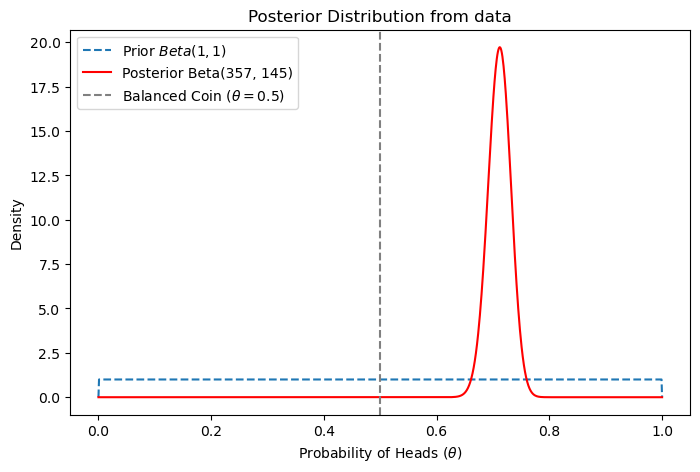

In [9]:
# Load the data
data = np.loadtxt('HW06_data.txt')
n_total = len(data)
h_successes = int(np.sum(data))
print(f"Total Flips (N): {n_total}")
print(f"Total Heads (h): {h_successes}")

# Setup grid and data
theta_space = np.linspace(0, 1, 1000)
observational_data = (n_total, h_successes)

# Define Flat Prior
def flat_prior(theta):
    return custom_beta_pdf(theta, alpha=1, beta_param=1)

# Run Solver
posterior_distribution = bayesian_inference_solver(
    prior_func=flat_prior,
    data=observational_data,
    theta_grid=theta_space
)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(theta_space, [flat_prior(t) for t in theta_space], label='Prior $Beta(1,1)$', linestyle='--')
plt.plot(theta_space, posterior_distribution, label=f'Posterior Beta({1+h_successes}, {1+(n_total-h_successes)})', color='red')
plt.axvline(0.5, color='gray', linestyle='--', label='Balanced Coin ($\\theta=0.5$)')
plt.title("Posterior Distribution from data")
plt.xlabel("Probability of Heads ($\\theta$)")
plt.ylabel("Density")
plt.legend()
plt.show()

No, the coin is not balanced coin. A balanced coin would produce a posterior distribution centered around 𝜃 = 0.5, here the posterior is centered around 𝜃 = 0.7.

# Part c

C:\Users\allst\AppData\Local\Temp\ipykernel_33708\2064201461.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization_constant = np.trapz(unnormalized_posterior, theta_grid)


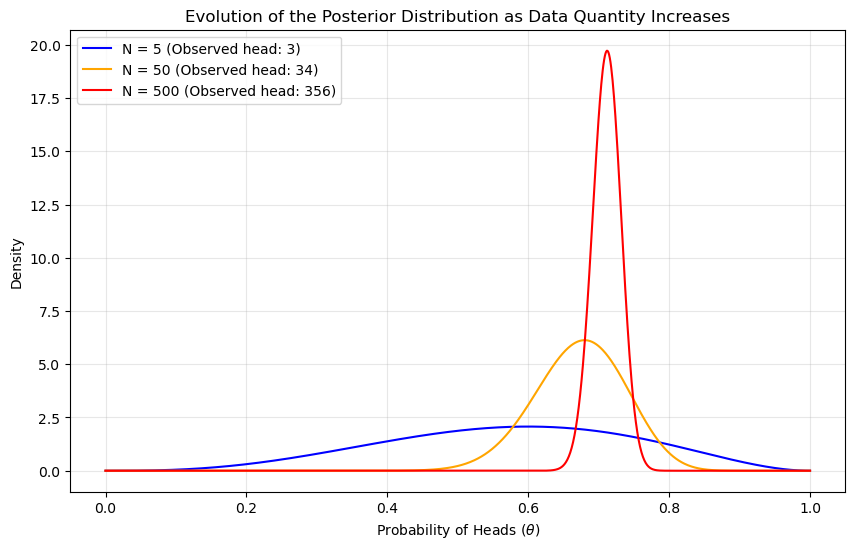

In [11]:
theta_space = np.linspace(0, 1, 1000)

def flat_prior(theta):
    return custom_beta_pdf(theta, alpha=1, beta_param=1)

sample_sizes = [5, 50, 500]
colors = ['blue', 'orange', 'red']

plt.figure(figsize=(10, 6))

# Loop through each sample size, slice the data, and compute the posterior
for n, color in zip(sample_sizes, colors):
    # Slice the first 'n' data points
    subset_data = data[:n]
    h_successes = int(np.sum(subset_data))
    
    # Run the solver on this subset
    observational_data = (n, h_successes)
    posterior_distribution = bayesian_inference_solver(
        prior_func=flat_prior,
        data=observational_data,
        theta_grid=theta_space
    )
    
    plt.plot(theta_space, posterior_distribution, color=color, 
             label=f'N = {n} (Observed head: {h_successes})')

plt.title("Evolution of the Posterior Distribution as Data Quantity Increases")
plt.xlabel("Probability of Heads ($\\theta$)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Here, we have used the flat prior. With only 5 coin fliped, the posterior is very broad and wide. The flat prior still exerts a noticeable influence. When we increase the number of flip, the posterior seperates from prior and begins to center firmly around the emperical mean of sample (becomes narrows and tall). When the number of flips are very large (N = 500), the initial choise of prior is completed washed out by data, the data drives the conclusion (the posterior is sharp, peaked spike centered at 0.7)

# Part d

C:\Users\allst\AppData\Local\Temp\ipykernel_33708\2064201461.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  normalization_constant = np.trapz(unnormalized_posterior, theta_grid)


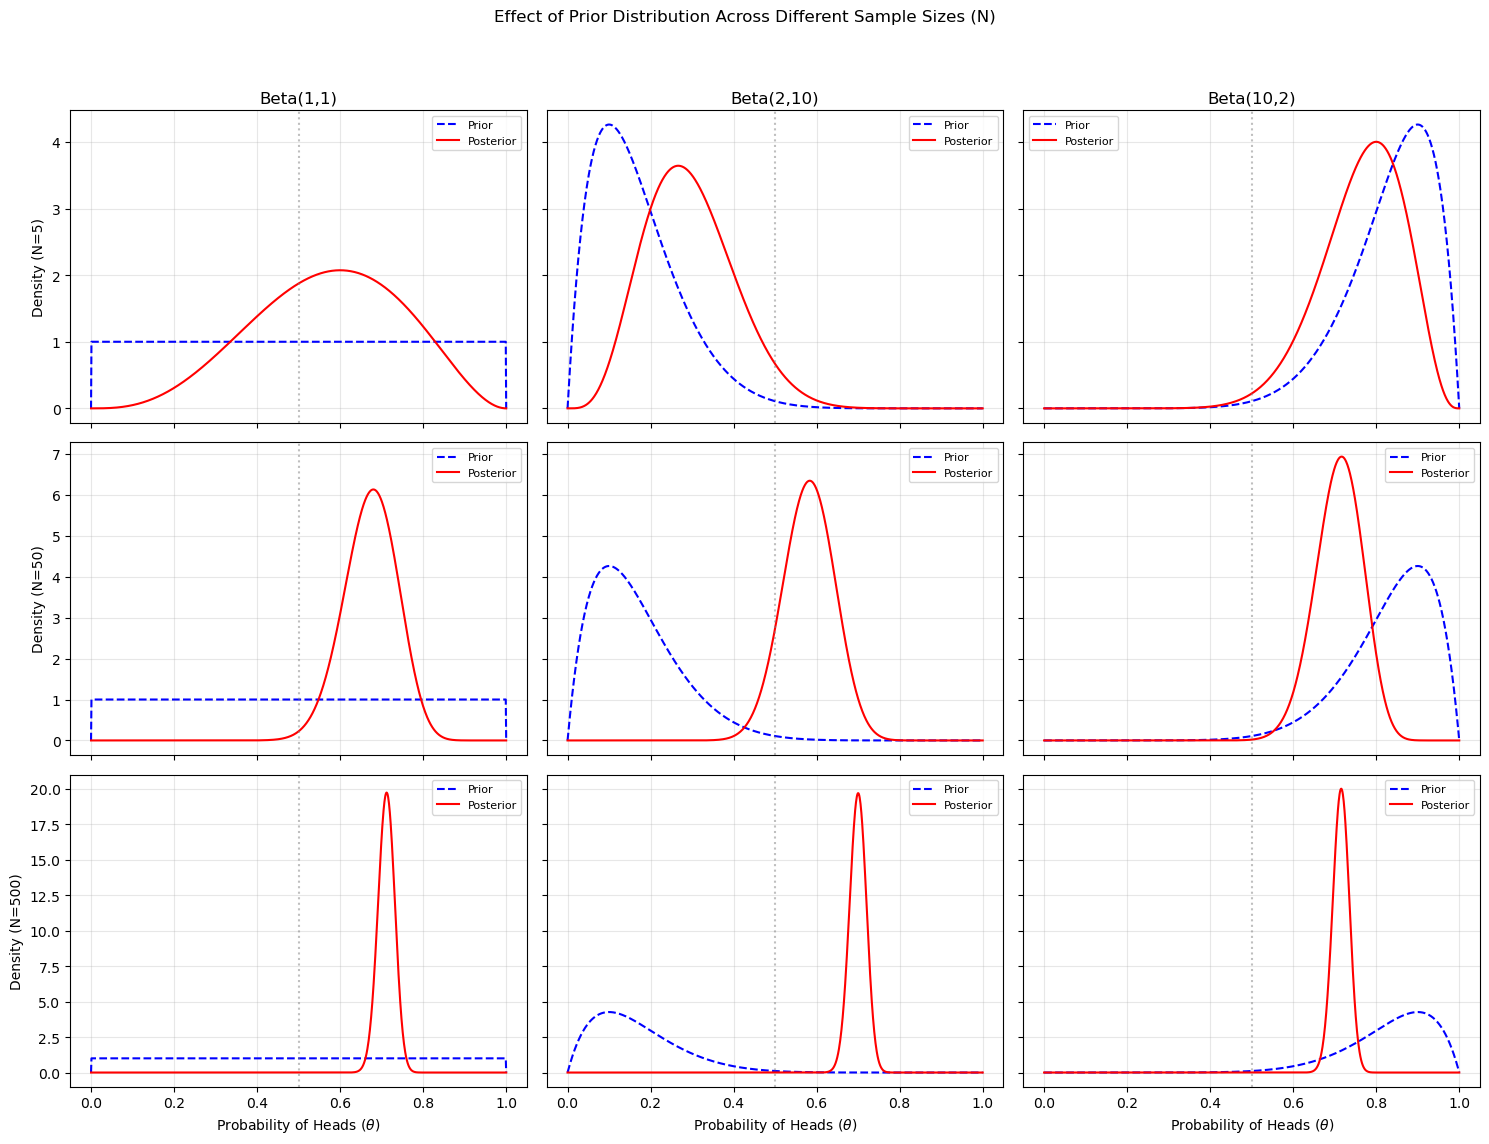

In [12]:
sample_sizes = [5, 50, 500]
# List of tuples: (alpha, beta, label)
prior_params = [
    (1, 1, 'Beta(1,1)'),
    (2, 10, 'Beta(2,10)'),
    (10, 2, 'Beta(10,2)')
]

# Set up a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey='row')
fig.suptitle('Effect of Prior Distribution Across Different Sample Sizes (N)')

for i, n in enumerate(sample_sizes):
    subset_data = data[:n]
    h_successes = int(np.sum(subset_data))
    observational_data = (n, h_successes)
    
    for j, (p_alpha, p_beta, p_label) in enumerate(prior_params):
        ax = axes[i, j]
        
        # Define the specific prior for this iteration
        def current_prior(theta):
            return custom_beta_pdf(theta, p_alpha, p_beta)
            
        posterior_dist = bayesian_inference_solver(
            prior_func=current_prior,
            data=observational_data,
            theta_grid=theta_space
        )
        
        
        prior_vals = [current_prior(t) for t in theta_space]
        ax.plot(theta_space, prior_vals, linestyle='--', color='blue', label='Prior')
        ax.plot(theta_space, posterior_dist, color='red', label='Posterior')
        
        # Formatting
        if i == 0:
            ax.set_title(p_label)
        if j == 0:
            ax.set_ylabel(f'Density (N={n})')
        if i == 2:
            ax.set_xlabel('Probability of Heads ($\\theta$)')
            
        ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Here we used three prior: Beta (1,1), Beta (2,10), and Beta (10,2). Similar to what we observed in part c, the prior dominateds for the small data limit. As an example of Beta (2,10) for N = 5, the posterior is closer to 0.2 even though the actual data has 3 heads out of 5 flips. Also for the large data limit, the prior has no effect. All three posteriors look identical.